# Step 1: Import Required Libraries

In [1]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Step 2: Load Dataset

In [2]:
# Load stock dataset from online source
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

# Read dataset
df = pd.read_csv(url)

# Display first five rows
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# Step 3: Use Closing Values / Sequence Data

In [3]:
# Select passenger values as time-series data
data = df['Passengers'].values.reshape(-1,1)

# Scale values between 0 and 1
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Step 4: Create Sequence Windowing

In [4]:
# Function to create sequences
def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

# Sequence length
seq_length = 10

# Create sequences
X, y = create_sequences(data_scaled, seq_length)

# Step 5: Train-Test Split

In [5]:
# Split data into train and test sets
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Step 6: Build LSTM Model

In [6]:
# Create Sequential model
model = Sequential()

# First LSTM layer
model.add(LSTM(64, return_sequences=True, input_shape=(seq_length,1)))

# Dropout layer
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(32))

# Output layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Step 7: Compile Model

In [7]:
# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Step 8: Train Model

In [8]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16,
    verbose=1
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 0.0671 - val_loss: 0.0901
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0188 - val_loss: 0.0308
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0156 - val_loss: 0.0371
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0118 - val_loss: 0.0502
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0106 - val_loss: 0.0300
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0098 - val_loss: 0.0269
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0094 - val_loss: 0.0290
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0088 - val_loss: 0.0273
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0088 - val_loss: 0.0271
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0081 - val_loss: 0.0271
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0085 - val_loss: 0.0276
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0085 - val_loss: 0.0271


# Step 9: Prediction

In [9]:
# Predict values
predicted = model.predict(X_test)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted)
actual = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


# Step 10: Evaluation Metrics

In [10]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("RMSE:", rmse)

RMSE: 82.93274353673227


# Step 11: Plot Loss Curve

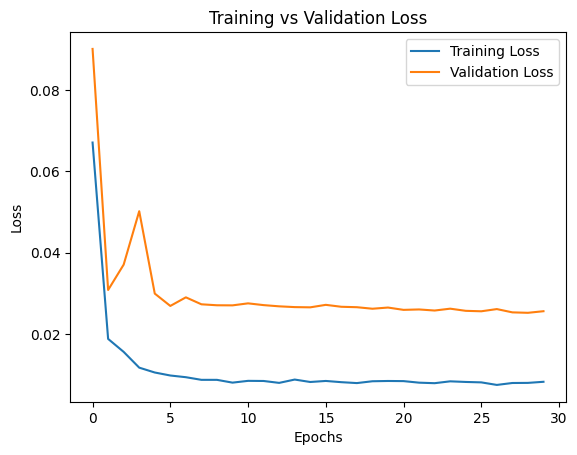

In [11]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Step 12: Plot Actual vs Predicted Values

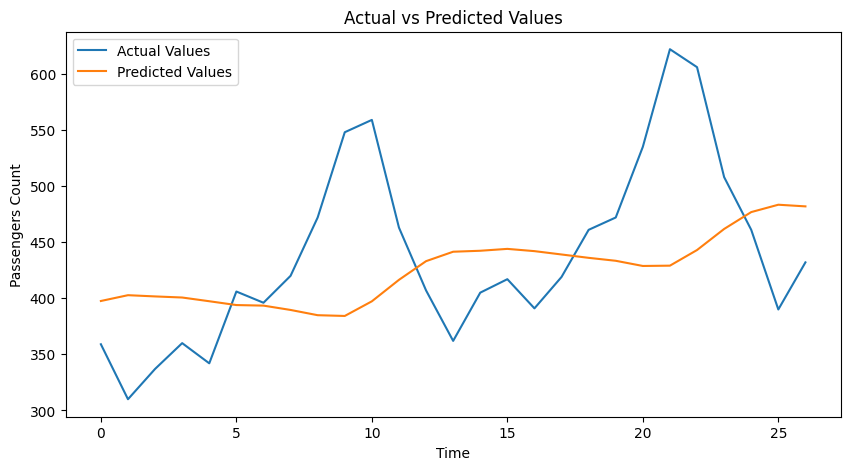

In [12]:
# Plot actual vs predicted
plt.figure(figsize=(10,5))

plt.plot(actual, label='Actual Values')
plt.plot(predicted, label='Predicted Values')

plt.title("Actual vs Predicted Values")
plt.xlabel("Time")
plt.ylabel("Passengers Count")
plt.legend()
plt.show()